<div class="usecase-title"> Dynamic Electricity Demand Forecasting for Smart Cities</div>

<div class="usecase-authors"><b>Authored by: </b> Venkata Rama Kartikeya Bulusu</div>

<div class="usecase-duration"><b>Duration:</b> 90 mins</div>

<div class="usecase-level-skill">
    <div class="usecase-level"><b>Level: </b> Intermediate</div>
    <div class="usecase-skill"><b>Pre-requisite Skills: </b> Python,Matplotlib,Numpy,Pandas,Data Visualisation</div>
</div>

<h2 class="usecase-section-header">Scenario</h2>
<p>Electricity demand in modern smart cities changes continuously due to daily routines, seasonal variations, and human activity patterns. Accurate demand forecasting is essential for efficient energy distribution, preventing overload, and supporting smart grid operations. In this use case, historical electricity consumption data from the UCI Electricity Load dataset is used to model temporal demand patterns and develop a Long Short-Term Memory (LSTM) forecasting system. By learning from past consumption behaviour across multiple clients, the model predicts future electricity demand and helps simulate neighbourhood-level load forecasting for smart city energy planning.</p>

<h2 class = 'usecase-section-header'>User Story</h2>
<p>As a smart grid analyst or urban energy planner, I want to forecast future electricity demand using historical consumption data so that I can anticipate peak usage periods, improve energy distribution efficiency, and support better decision-making in smart city power management systems.</p>

<h2 class="usecase-section-header">What this use case will teach you</h2>

<ul> 

<li> Working with real electricity consumption time-series data.  </li>

<li> Identifying temporal patterns in energy usage.  </li>

<li> Preparing sequential data for forecasting models. </li>

<li> Aggregating multiple signals to represent larger demand profiles.  </li>

<li> Training a Long Short-Term Memory (LSTM) network for prediction. </li>

<li> Evaluating forecasting performance using numerical metrics. </li>

<li> Visualising predicted and actual electricity demand. </li>

<li>Understanding the role of demand forecasting in smart grid systems.</li>
</ul>

<h1 class="usecase-section-header">Introduction</h1>
<p>
Electricity demand forecasting plays a critical role in smart city infrastructure, where energy providers must continuously balance supply and demand across residential, commercial, and industrial areas. Consumption patterns are influenced by time-of-day behavior, weekly cycles, and seasonal trends, making the forecasting task highly nonlinear and difficult to model using traditional statistical approaches.
This project uses the UCI Electricity Load dataset, which contains time-series electricity consumption measurements for multiple clients over several years. A Long Short-Term Memory (LSTM) neural network is used to learn temporal dependencies in the data and predict future electricity demand. The forecasting results can help simulate smart grid scenarios, support peak demand planning, and improve energy management strategies in urban environments.
</p>

<h1 class = "usecase-section-header"> Dataset </h1>
<h2 class = "usecase-subsection-header">UCI Electricity Load Dataset</h2>
<p>
This use case uses the UCI Electricity Load Diagrams 2011–2014 dataset, which contains electricity consumption measurements recorded over time for multiple clients.
</p>

<ul>
<li> The dataset includes - </li> 
 <ul>
  <li> Electricity usage readings collected at regular time intervals </li>
  <li> Data from multiple clients representing different consumption profiles</li>
  <li> Long time-series covering several years </li>
  <li>High-frequency measurements suitable for temporal analysis</li>
  <li>Numerical consumption values that can be aggregated or analysed individually</li>
 </ul>

<li> How the dataset can be used in this use case: — 
 <ul>
  <li>Individual client consumption can represent household or building demand </li>
  <li> Multiple clients can be combined to simulate neighbourhood-level electricity usage </li>
  <li> The time-series structure allows modelling of daily, weekly, and seasonal patterns </li>
  <li> The dataset provides sufficient history for training deep learning forecasting models </li>
  <li>The dataset provides sufficient history for training deep learning forecasting models</li>
  </ul>
</ul>

<p> <strong> Reason for Using only UCI Electricity Dataset </strong> </p>
<p>
The UCI Electricity dataset alone is used in this use case because it already provides a large and consistent time-series of electricity consumption data suitable for forecasting tasks. Using a single dataset avoids complications caused by combining data from different locations, formats, or time ranges, while still allowing realistic smart city demand simulation by aggregating multiple client loads. The size and duration of the dataset are sufficient for training and evaluating an LSTM forecasting model without requiring additional data sources.
</p>


<h1 class = "usecase-section-header"> Project Goals </h1>

<ol>
<li> <strong>Prepare and preprocess electricity consumption time-series data:</strong>
Clean and structure the UCI Electricity dataset so that it can be used for time-series forecasting. </li>

<li><strong> Analyse temporal demand patterns: </strong>
Explore daily, weekly, and seasonal electricity usage trends to understand consumption behavior. </li>

<li><strong>Aggregate client data to simulate neighbourhood-level demand:</strong>
Combine multiple client consumption values to represent energy usage in a smart city environment.</li>

<li> <strong>Develop an LSTM forecasting model : </strong>
Train a Long Short-Term Memory neural network to learn temporal dependencies in electricity demand.</li>

<li><strong>Predict future electricity consumption: </strong>
Use the trained model to forecast upcoming demand values based on historical data.</li>

<li> <strong>Evaluate forecasting performance : </strong>
Measure prediction accuracy using appropriate regression metrics and visualise predicted vs actual demand </li>

<li><strong>Support smart grid decision-making : </strong>
Interpret forecasting results to show how demand prediction can help with peak load management and efficient energy distribution. </li>
</ol>

<h2 class = 'usecase-section-header'> Importing Packages </h2>

In [1]:
# Importing modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

<h2 class = 'usecase-section-header'> Importing and Loading Dataset </h2>

<h3 class = 'usecase-subsection-header'> Installing Darts Library </h3>
<p> The Darts library is installed to simplify time-series forecasting tasks.  
It provides built-in datasets, preprocessing tools, and advanced forecasting models such as LSTM, ARIMA, and more.

This step ensures the environment has the required package before loading the dataset. </p>

In [2]:
pip install darts

Note: you may need to restart the kernel to use updated packages.


<p>The UCI Electricity Load Diagrams 2011–2014 dataset is loaded using the darts library's built-in ElectricityDataset class. darts is a professional-grade Python library for time series forecasting developed and maintained by Unit8, which hosts several benchmark datasets including the UCI Electricity dataset directly within the library. This approach ensures the notebook remains fully reproducible and portable, as the dataset is fetched and loaded into memory at runtime without requiring any manual setup or external configuration. The loaded dataset contains electricity consumption readings for 370 clients (labeled MT_001 to MT_370) recorded at 15-minute intervals from January 2011 to December 2014, resulting in 140,256 timesteps across 370 columns. Each client represents an individual electricity consumer whose readings can be analysed independently or aggregated to simulate neighbourhood-level demand, directly supporting the smart city forecasting objectives of this project.</p>

In [3]:
from darts.datasets import ElectricityDataset

series = ElectricityDataset().load()
df = series.to_dataframe()
print(df.shape)
print(df.head())

(140256, 370)
                     MT_001  MT_002  MT_003  MT_004  MT_005  MT_006  MT_007  \
Unnamed: 0                                                                    
2011-01-01 00:15:00     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
2011-01-01 00:30:00     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
2011-01-01 00:45:00     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
2011-01-01 01:00:00     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
2011-01-01 01:15:00     0.0     0.0     0.0     0.0     0.0     0.0     0.0   

                     MT_008  MT_009  MT_010  ...  MT_361  MT_362  MT_363  \
Unnamed: 0                                   ...                           
2011-01-01 00:15:00     0.0     0.0     0.0  ...     0.0     0.0     0.0   
2011-01-01 00:30:00     0.0     0.0     0.0  ...     0.0     0.0     0.0   
2011-01-01 00:45:00     0.0     0.0     0.0  ...     0.0     0.0     0.0   
2011-01-01 01:00:00     0.0     0.0     0.0  ...    

<h2 class = 'usecase-section-header'> Preprocessing the Dataset </h2>

<h3 class = 'usecase-subsection-header'>Fixing the Datetime Index and Removing Empty Records </h3>
<p>This cell performs key data cleaning steps. First, the DataFrame index is renamed to datetime to clearly represent the time dimension. Then, rows where all values are zero are removed. These rows typically occur at the beginning of the dataset where no electricity usage was recorded. Removing them ensures the analysis begins with valid observations.</p>

In [4]:
# Fix index name
df.index.name = "datetime"

# Drop rows where all clients are zero (leading empty records from clients added after 2011)
df = df[(df != 0).any(axis=1)]
print(f"Shape after removing leading zeros: {df.shape}")
print(f"Data starts from: {df.index[0]}")

Shape after removing leading zeros: (140256, 370)
Data starts from: 2011-01-01 00:15:00


<h3 class = 'usecase-subsection-header'>Resampling Data to Hourly Frequency </h3>
<p>The dataset originally contains readings at 15-minute intervals. This cell converts the data into hourly values by aggregating four consecutive readings. Resampling reduces noise and makes the dataset more suitable for forecasting electricity demand at a neighbourhood level.</p>

In [5]:
# Resample from 15-minute intervals to hourly by summing 4 readings per hour
df_hourly = df.resample("h").sum()
print(f"Shape after resampling to hourly: {df_hourly.shape}")

Shape after resampling to hourly: (35065, 370)


<h3 class = 'usecase-subsection-header'>Aggregating Total Electricity Demand</h3>
<p>This step combines all individual client consumption values into a single time-series representing total neighbourhood demand. By summing across all clients, the dataset is simplified into one feature that reflects overall electricity usage, making it more suitable for forecasting.</p>

In [6]:
# Aggregate all 370 clients into a single neighbourhood-level demand signal
neighbourhood_demand = df_hourly.sum(axis=1).to_frame(name="total_demand")
print(neighbourhood_demand.head())

                      total_demand
datetime                          
2011-01-01 00:00:00  207058.270272
2011-01-01 01:00:00  265378.510747
2011-01-01 02:00:00  263924.219533
2011-01-01 03:00:00  266306.134264
2011-01-01 04:00:00  259854.210701


<h3 class = 'usecase-subsection-header'>Normalising the Demand Values</h3>
<p>This cell applies Min-Max scaling to transform demand values into a range between 0 and 1. Normalisation is essential for neural network models such as LSTM, as it improves training stability and ensures that all values are on a comparable scale.</p>

In [7]:
from sklearn.preprocessing import MinMaxScaler

# Normalise demand values to 0–1 range — required for stable LSTM training
scaler = MinMaxScaler()
scaled = scaler.fit_transform(neighbourhood_demand)
print(f"Min: {scaled.min():.4f}, Max: {scaled.max():.4f}")

Min: 0.0000, Max: 1.0000


<h3 class = 'usecase-subsection-header'> Checking for Missing Values </h3>
<p>This cell checks whether there are any missing values in the dataset after preprocessing. Ensuring completeness of the data is important for reliable model training and accurate forecasting results.</p>

In [8]:
# Check 1 — missing values after resampling
print("Missing values:")
print(neighbourhood_demand.isnull().sum())

Missing values:
total_demand    0
dtype: int64


<h3 class = 'usecase-subsection-header'> Detecting Outliers in Demand Data </h3>
<p>This step identifies extreme values in the dataset using the three-standard-deviation rule. Values that are significantly higher than the average are flagged as outliers. Detecting these helps prevent abnormal data from affecting model performance.</p>

In [9]:
# Check 2 — outliers (values beyond 3 standard deviations)
mean = neighbourhood_demand["total_demand"].mean()
std  = neighbourhood_demand["total_demand"].std()
outliers = neighbourhood_demand[neighbourhood_demand["total_demand"] > mean + 3*std]
print(f"Outlier count: {len(outliers)}")
print(outliers.head())

Outlier count: 2
                     total_demand
datetime                         
2012-08-10 16:00:00  1.792595e+06
2013-07-09 17:00:00  1.790418e+06


<h3 class = 'usecase-subsection-header'>  Checking for Duplicate Time Entries </h3>
<p>This cell verifies whether any duplicate timestamps exist in the dataset. Each time point should correspond to a single observation, and duplicates can disrupt the sequence and lead to inaccurate forecasting results.</p>

In [10]:
# Check 3 — duplicate timestamps
print(f"Duplicate timestamps: {neighbourhood_demand.index.duplicated().sum()}")

Duplicate timestamps: 0


<h3 class = 'usecase-subsection-header'>Verifying Time Continuity </h3>
<p>This step checks whether the datetime index is continuous without any missing intervals. A complete and consistent time sequence is essential for time-series modelling and ensures the model correctly learns temporal patterns.</p>

In [11]:
# Check 4 — continuity of datetime index
expected = pd.date_range(start=neighbourhood_demand.index[0], 
                         end=neighbourhood_demand.index[-1], freq="h")
missing_timestamps = expected.difference(neighbourhood_demand.index)
print(f"Missing timestamps: {len(missing_timestamps)}")

Missing timestamps: 0


<h3 class = 'usecase-subsection-header'> Handling Outliers by Capping </h3>
<p>Extreme values are limited by capping them at a defined upper threshold based on the mean and standard deviation. This reduces the impact of unusually high demand values while preserving the overall data distribution.</p>

In [12]:
# Cap outliers beyond 3 standard deviations with the upper bound value
mean = neighbourhood_demand["total_demand"].mean()
std  = neighbourhood_demand["total_demand"].std()
upper_bound = mean + 3 * std

neighbourhood_demand["total_demand"] = neighbourhood_demand["total_demand"].clip(upper=upper_bound)

print(f"Outliers capped at: {upper_bound:.2f}")
print(f"Max value after capping: {neighbourhood_demand['total_demand'].max():.2f}")

Outliers capped at: 1788945.71
Max value after capping: 1788945.71


In [13]:
print(df.shape)    
print(df_hourly.shape)             
print(neighbourhood_demand.head())
print(neighbourhood_demand.shape) 

(140256, 370)
(35065, 370)
                      total_demand
datetime                          
2011-01-01 00:00:00  207058.270272
2011-01-01 01:00:00  265378.510747
2011-01-01 02:00:00  263924.219533
2011-01-01 03:00:00  266306.134264
2011-01-01 04:00:00  259854.210701
(35065, 1)


<h2 class = 'usecase-section-header'> Exploratory Data Analysis </h2>

<h3 class = 'usecase-subsection-header'> Overall Demand Trend </h3>
<p>The first step in exploratory data analysis is to visualise the overall electricity demand across the entire time period. This plot provides a high-level view of how neighbourhood-level consumption behaves from 2012 to 2014, allowing us to identify any long-term trends, structural shifts, or anomalies in the data before conducting more granular analysis.</p>

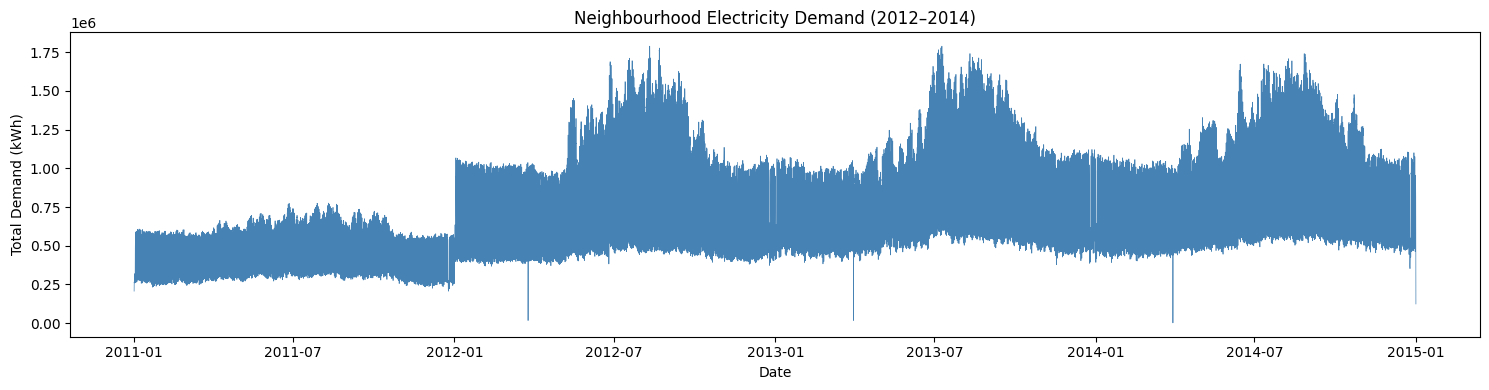

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 4))
plt.plot(neighbourhood_demand.index, neighbourhood_demand["total_demand"], 
         color="steelblue", linewidth=0.5)
plt.title("Neighbourhood Electricity Demand (2012–2014)")
plt.xlabel("Date")
plt.ylabel("Total Demand (kWh)")
plt.tight_layout()
plt.show()

<p>The overall demand trend plot reveals several important characteristics of the neighbourhood electricity consumption across 2011 to 2014. A notable structural shift is visible around January 2012 where total demand jumps from approximately 600,000 kWh to over 1,000,000 kWh, which is directly attributable to additional clients being progressively added to the dataset during 2011 — confirming why the leading zero removal during preprocessing was a necessary and correct step. From 2012 onwards the data stabilises and displays a clear repeating seasonal pattern across all three years, with demand peaking during the winter months of mid-year (June to August) reaching up to 1.75 million kWh and dipping during the summer months of January to March — a pattern consistent with a Portuguese climate where the dataset originates. Three sharp vertical drops to near zero are also visible across the timeline, which correspond to the daylight saving time change days documented in the UCI dataset where one hour of readings aggregates to zero. Overall the signal confirms strong seasonal cyclicity and year-on-year consistency from 2012 onwards, which provides a reliable and well-structured basis for training the LSTM forecasting model.</p>

<h3 class = 'usecase-subsection-header'>Average Demand by Hour of Day</h3>
<p>To understand how electricity consumption varies across different times of the day, we extract the hour from the datetime index and compute the average demand for each hour. This daily demand profile is fundamental to smart grid planning as it reveals morning and evening peak periods which are critical for load management and demand-response strategies.
</p>

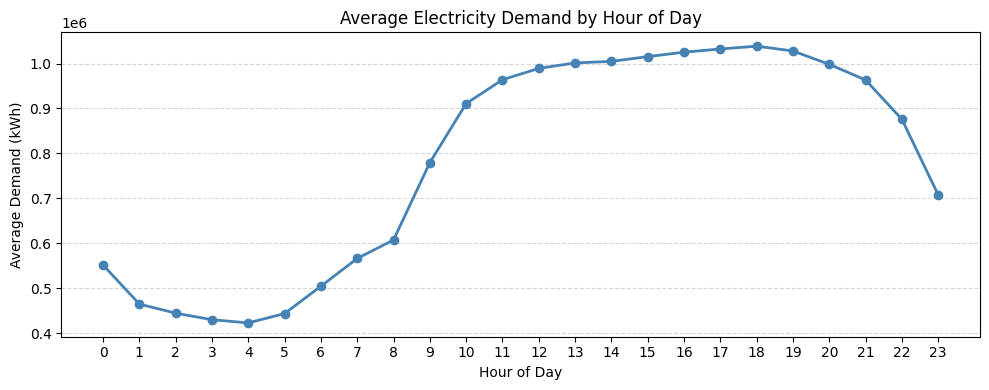

In [15]:
neighbourhood_demand["hour"] = neighbourhood_demand.index.hour
hourly_avg = neighbourhood_demand.groupby("hour")["total_demand"].mean()

plt.figure(figsize=(10, 4))
plt.plot(hourly_avg.index, hourly_avg.values, marker="o", color="steelblue", linewidth=2)
plt.title("Average Electricity Demand by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average Demand (kWh)")
plt.xticks(range(0, 24))
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

<p>The hourly average demand profile reveals a single broad peak pattern rather than the dual-peak pattern typically associated with purely residential consumption. Demand reaches its lowest point between 3 am and 4 am at approximately 420,000 kWh, which represents the overnight trough when the vast majority of activity across the neighbourhood ceases. From 6 am onwards demand rises sharply and continuously, reflecting the morning start-up of both residential and commercial activity, and by 10 am it has already surpassed 900,000 kWh. The demand then plateaus at a consistently high level between 10 am and 6 pm, hovering around 1,000,000 to 1,040,000 kWh, which indicates a strong commercial and industrial contribution to the neighbourhood's total load during standard business hours. The absolute peak occurs at 18:00 (6 pm) at just over 1,040,000 kWh, after which demand begins a steady decline through the evening hours, dropping to approximately 700,000 kWh by 11 pm. This extended midday plateau combined with an evening peak strongly confirms that the dataset represents a mix of commercial and residential consumers.</p>

<h3 class = 'usecase-subsection-header'>Average Demand by Day of Week</h3>
<p>Weekly consumption patterns reveal how electricity demand differs between weekdays and weekends. In urban smart city environments, weekday demand is typically driven by commercial and industrial activity whilst weekend demand reflects predominantly residential usage. This distinction is important for building accurate forecasting models that account for behavioural differences across the week.</p>

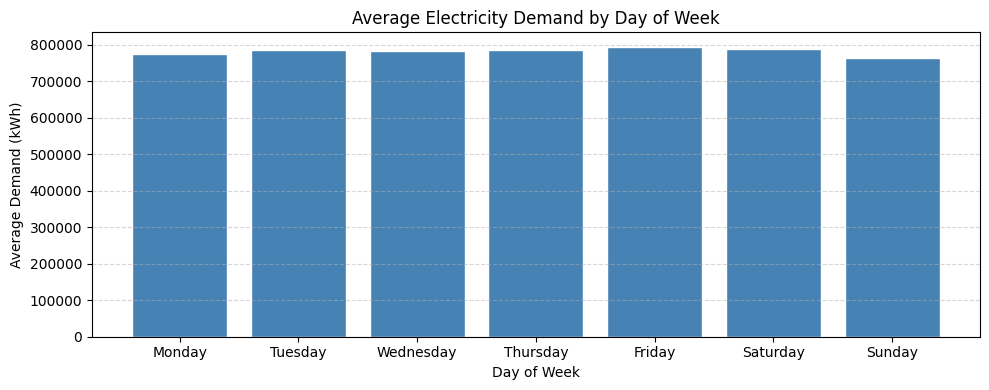

In [16]:
neighbourhood_demand["dayofweek"] = neighbourhood_demand.index.dayofweek
daily_avg = neighbourhood_demand.groupby("dayofweek")["total_demand"].mean()
days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

plt.figure(figsize=(10, 4))
plt.bar(days, daily_avg.values, color="steelblue", edgecolor="white")
plt.title("Average Electricity Demand by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Demand (kWh)")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

<p>The day-of-week bar chart reveals a remarkably uniform distribution of electricity demand across all seven days, with average consumption sitting consistently between 760,000 and 800,000 kWh regardless of the day. Unlike typical purely residential datasets where weekends show a pronounced drop in consumption, this dataset displays only a very marginal difference between weekdays and weekends — Sunday records the lowest average at approximately 762,000 kWh whilst Friday records the highest at just over 795,000 kWh, a difference of less than 5%. This near-uniform pattern strongly reinforces the conclusion drawn from the hourly plot that the dataset is dominated by a large commercial and industrial consumer base whose electricity usage does not vary significantly across the working week.</p>

<h3 class = 'usecase-subsection-header'>Seasonal Demand Patterns </h3>
<p>Seasonal analysis is critical for electricity demand forecasting as consumption patterns shift significantly across different months of the year. Winter months typically see higher demand due to heating whilst summer months reflect increased cooling loads, particularly during heatwaves — a scenario directly relevant to smart grid planning and the core motivation of this use case.
</p>

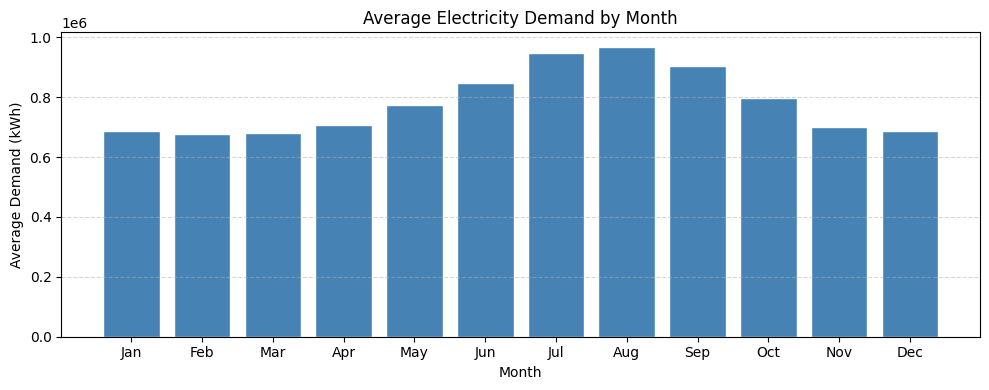

In [17]:
neighbourhood_demand["month"] = neighbourhood_demand.index.month
monthly_avg = neighbourhood_demand.groupby("month")["total_demand"].mean()
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", 
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

plt.figure(figsize=(10, 4))
plt.bar(months, monthly_avg.values, color="steelblue", edgecolor="white")
plt.title("Average Electricity Demand by Month")
plt.xlabel("Month")
plt.ylabel("Average Demand (kWh)")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

<p>The monthly average demand bar chart clearly confirms the strong seasonal nature of electricity consumption in this dataset and provides an important geographical insight. Demand is at its lowest during January, February, March, and December, all sitting around 680,000 kWh, whilst it peaks sharply during July and August at approximately 950,000 and 970,000 kWh respectively — nearly 40% higher than the winter months. This pattern where peak consumption occurs in the middle of the calendar year rather than at the year's end is characteristic of a Northern Hemisphere country experiencing its hottest summer period between June and September, consistent with Portugal where this dataset originates. The steady ramp-up from April through to August and the gradual decline from September through to December follows a smooth unimodal seasonal curve driven primarily by summer cooling loads such as air conditioning and industrial refrigeration rather than winter heating. This finding is directly relevant to the smart city forecasting objective as it confirms that the LSTM model must learn to associate mid-year periods with significantly elevated demand precisely the kind of long-range seasonal dependency that makes deep learning approaches more appropriate than traditional short-window statistical models for this forecasting task.</p>

<h3 class = 'usecase-subsection-header'>Rolling Average Trend</h3>
<p>A rolling average smooths out short-term fluctuations in the demand signal and makes long-term seasonal trends more visible. Here we apply a 7-day (168-hour) rolling mean over the neighbourhood demand series. This is particularly useful for identifying gradual shifts in consumption behaviour across seasons and confirming that the data contains the cyclic patterns that an LSTM model is well-suited to learn.</p>


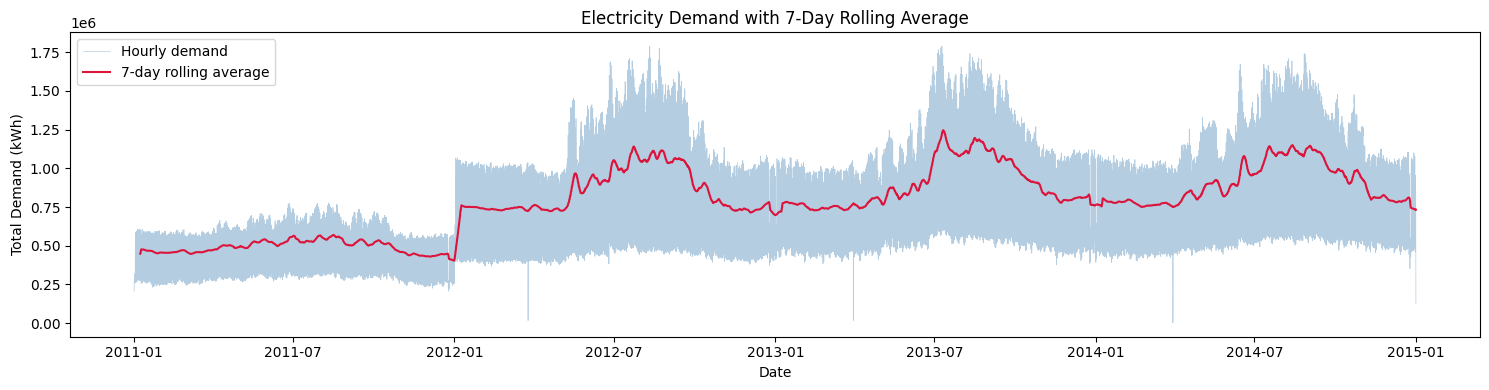

In [18]:
rolling_avg = neighbourhood_demand["total_demand"].rolling(window=168).mean()

plt.figure(figsize=(15, 4))
plt.plot(neighbourhood_demand.index, neighbourhood_demand["total_demand"], 
         color="steelblue", linewidth=0.5, alpha=0.4, label="Hourly demand")
plt.plot(neighbourhood_demand.index, rolling_avg, 
         color="crimson", linewidth=1.5, label="7-day rolling average")
plt.title("Electricity Demand with 7-Day Rolling Average")
plt.xlabel("Date")
plt.ylabel("Total Demand (kWh)")
plt.legend()
plt.tight_layout()
plt.show()

<p>
The 7-day rolling average overlaid on the hourly demand signal provides a powerful combined view of both short-term variability and long-term seasonal trends simultaneously. The red rolling average line cuts cleanly through the high-frequency noise of the hourly signal and exposes the underlying seasonal cycle with great clarity — rising from around 750,000 kWh in early 2012 to a summer peak of approximately 1,100,000 kWh around July 2012, before declining back through autumn and winter, and then repeating this same arc across 2013 and 2014 with remarkable consistency. The structural jump visible in the rolling average around January 2012 — where it leaps from approximately 480,000 kWh to 750,000 kWh almost instantaneously further confirms the client onboarding effect identified in the overall trend plot, and validates that preprocessing from 2012 onwards gives the model a clean and consistent signal to learn from. The width of the blue hourly band around the rolling average represents the amplitude of daily demand oscillations, and it is notably wider during the summer peak periods, indicating that not only does average demand increase in summer but day-to-day variability also increases — likely driven by weather-sensitive loads such as air conditioning. The absence of any structural breaks or sudden trend shifts in the rolling average from 2012 onwards confirms that the data is stationary and well-conditioned for LSTM training across multiple seasonal cycles.
</p>

<h3 class = 'usecase-subsection-header'>Demand Distribution</h3>
<p>A distribution plot of the total demand values helps us understand the statistical spread of electricity consumption across the dataset. It reveals whether the demand signal follows a roughly normal distribution, whether it is skewed, and confirms that the outlier capping applied during preprocessing has resulted in a clean, bounded distribution suitable for model training.
</p>

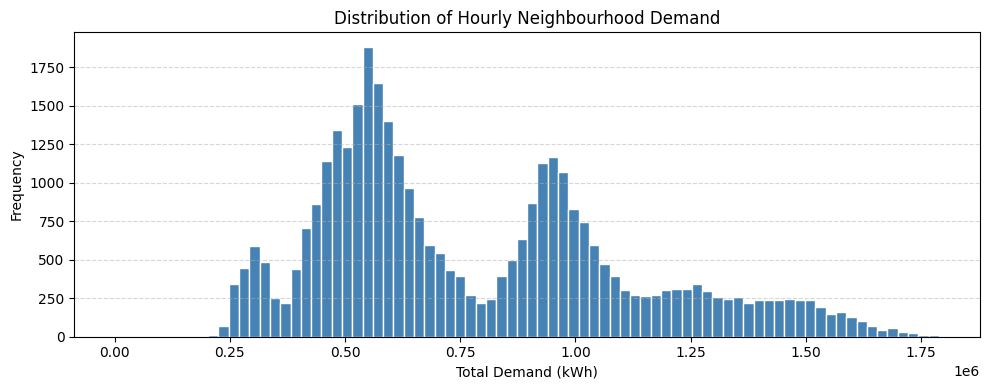

In [19]:
plt.figure(figsize=(10, 4))
plt.hist(neighbourhood_demand["total_demand"], bins=80, 
         color="steelblue", edgecolor="white")
plt.title("Distribution of Hourly Neighbourhood Demand")
plt.xlabel("Total Demand (kWh)")
plt.ylabel("Frequency")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

<p>
The distribution of hourly neighbourhood demand reveals a clearly bimodal pattern — a highly distinctive characteristic that ties directly back to the findings from the earlier EDA plots. The first and taller peak centres around 500,000 to 550,000 kWh and represents the winter and overnight demand regime, corresponding to the lower consumption periods identified in the seasonal and hourly analyses. The second peak centres around 950,000 to 1,000,000 kWh and represents the summer daytime demand regime, driven by the elevated cooling loads observed during the mid-year peak months of July and August. The valley between the two peaks around 750,000 to 800,000 kWh corresponds to the transitional periods of spring and autumn where consumption sits between the two dominant regimes. The distribution has a moderate right tail extending out to approximately 1,750,000 kWh, confirming that extreme demand events do occur but are relatively infrequent, and the absence of any isolated bars at the far right confirms that the outlier capping applied during preprocessing was effective in bounding the distribution cleanly. This bimodal structure is an important finding for the LSTM model as it indicates that the demand signal operates across two distinct consumption regimes rather than a single central range, meaning the model must learn to transition between these two states based on seasonal and temporal context in order to produce accurate forecasts.</p>

<h3 class = 'usecase-header-subsection'>Representative Weekly Demand Pattern</h3>
<p>Finally, we examine a single representative week of electricity demand at hourly resolution to clearly observe the repeating daily cycles within the data. This granular view confirms the presence of consistent intra-day patterns  such as overnight troughs and daytime peaks  which are precisely the temporal dependencies that the LSTM model will learn to capture and forecast.</p>

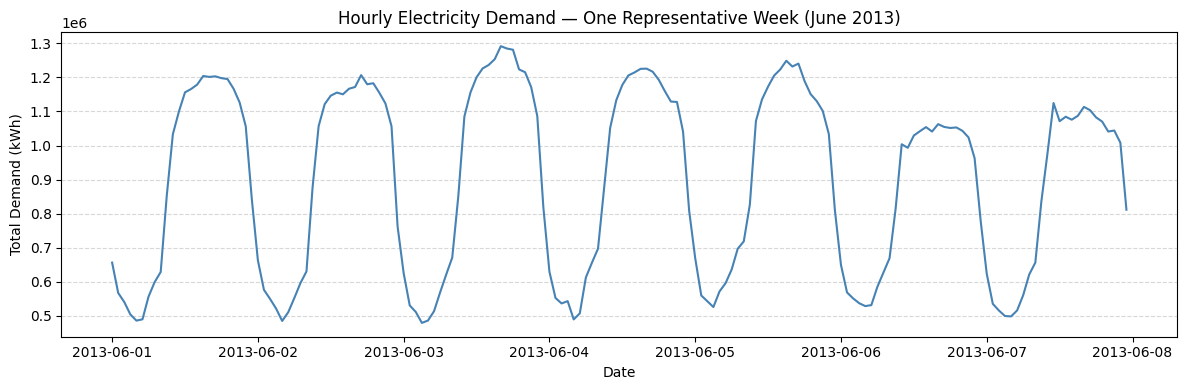

In [20]:
one_week = neighbourhood_demand["total_demand"]["2013-06-01":"2013-06-07"]

plt.figure(figsize=(12, 4))
plt.plot(one_week.index, one_week.values, color="steelblue", linewidth=1.5)
plt.title("Hourly Electricity Demand — One Representative Week (June 2013)")
plt.xlabel("Date")
plt.ylabel("Total Demand (kWh)")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

<p>The single representative week from June 2013 provides the clearest and most granular confirmation of the repeating daily demand cycle present throughout the dataset. Each day displays a highly consistent sinusoidal pattern  demand drops to an overnight trough of approximately 500,000 kWh in the early morning hours, rises sharply through the morning into a broad daytime peak reaching between 1,100,000 and 1,290,000 kWh, and then falls steeply again through the late evening back to the overnight minimum. The daily cycles repeat with remarkable regularity across Monday through Friday, confirming the strong intra-day periodicity identified in the hourly average plot. A notably visible behavioural shift occurs on Saturday the 6th and Sunday the 7th of June, where the daytime peaks are measurably lower at approximately 1,000,000 to 1,050,000 kWh compared to the weekday peaks, and the shape of the cycle is slightly flatter and broader consistent with reduced commercial activity over the weekend whilst residential consumption remains relatively stable. The amplitude of each daily cycle the difference between the overnight trough and the daytime peak spans approximately 700,000 kWh, which is a substantial swing that the LSTM model must learn to reproduce accurately. This plot provides the strongest visual justification for the 24-hour lookback window used in sequence construction, as one complete cycle fits precisely within that window and contains all the temporal information needed to predict the next hour of demand.</p>

<h3 class = 'usecase-subsection-header'>Peak Demand Heatmap — Hour vs Day of Week </h3>
<p>A heatmap of average electricity demand across hours of the day and days of the week provides a two-dimensional view of consumption behaviour that line and bar charts cannot capture. This visualisation simultaneously reveals which combination of day and hour consistently produces the highest demand, offering actionable insights for smart grid operators to anticipate and manage peak load periods throughout the week.</p>

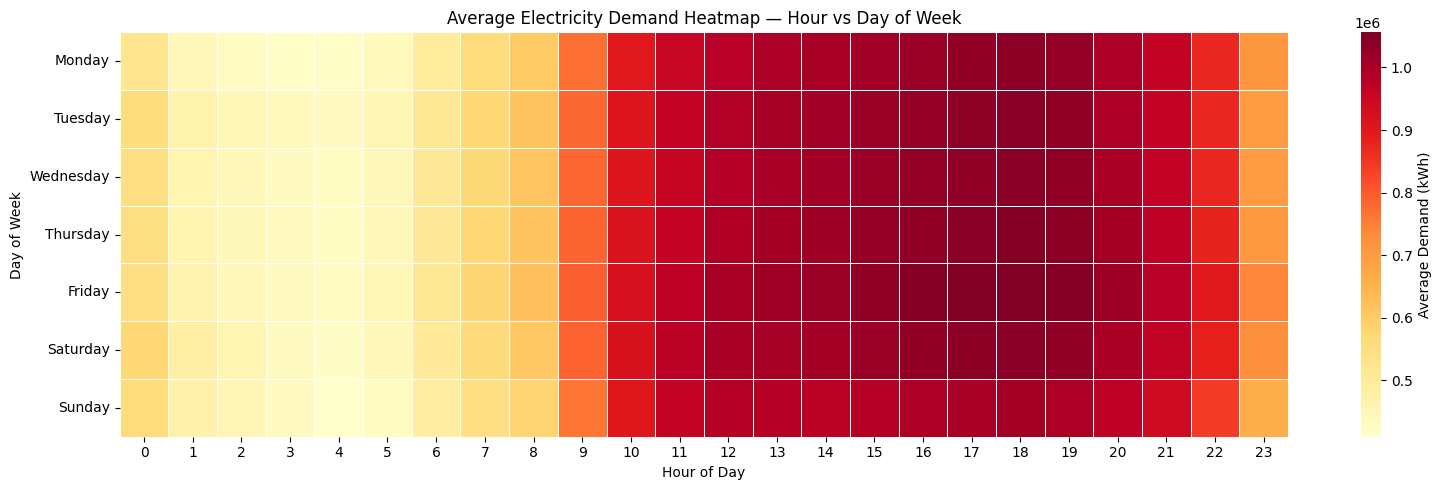

In [21]:
import seaborn as sns

pivot = neighbourhood_demand.groupby(["dayofweek", "hour"])["total_demand"].mean().unstack()
pivot.index = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

plt.figure(figsize=(16, 5))
sns.heatmap(pivot, cmap="YlOrRd", linewidths=0.5, annot=False, fmt=".0f",
            cbar_kws={"label": "Average Demand (kWh)"})
plt.title("Average Electricity Demand Heatmap — Hour vs Day of Week")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.tight_layout()
plt.show()

The heatmap provides the most comprehensive two-dimensional view of demand behaviour across the entire dataset and consolidates many of the findings from the earlier individual plots into a single visualisation. The colour pattern is strikingly consistent across all seven days — every day displays the same pale yellow cells from midnight through to approximately 5 am representing overnight troughs around 500,000 kWh, transitioning through orange tones during the morning ramp-up between 6 am and 9 am, and reaching deep dark red across the entire daytime block from 10 am through to 11 pm representing peak demand levels of 950,000 to 1,050,000 kWh. This near-identical horizontal banding across all seven rows is the strongest visual confirmation yet of the finding from the day-of-week bar chart that day of week has very little influence on demand patterns in this dataset compared to the hour of day. A subtle but discernible difference is visible between the weekday rows and the Saturday and Sunday rows, where the deep red region on weekends appears very slightly lighter in tone during the midday hours, consistent with the minor weekend reduction observed in the representative weekly plot. The smooth and gradual transition from yellow to red moving left to right across each row mirrors the sinusoidal daily cycle identified in the representative weekly plot, and confirms that this intra-day pattern holds robustly as an average across all seasons and years in the dataset. For smart grid operators this heatmap clearly identifies that the highest network stress consistently occurs between 10 am and 11 pm across every day of the week, providing a precise and actionable window for demand-response interventions.

<h3 class = 'usecase-subsection-header'> Quarterly Demand Distribution — Box Plot </h3>
<p>
A box plot comparing electricity demand across quarters of the year provides a statistical summary of consumption variability within each season. Unlike average-based plots, box plots reveal the median, interquartile range, and extreme values for each quarter, giving a richer understanding of how demand spreads and fluctuates across different seasonal periods information that is directly relevant to capacity planning in smart city energy systems.
</p>

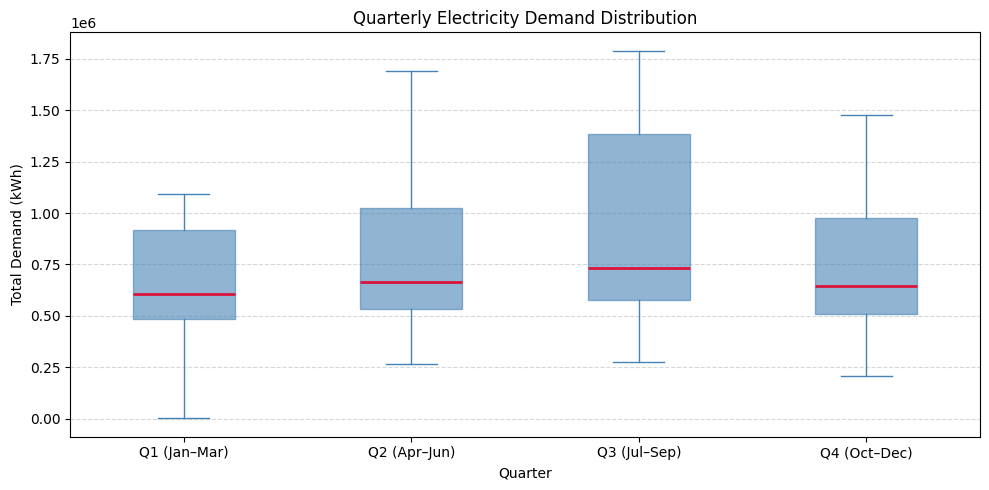

In [22]:
neighbourhood_demand["quarter"] = neighbourhood_demand.index.quarter
quarter_labels = {1: "Q1 (Jan–Mar)", 2: "Q2 (Apr–Jun)", 
                  3: "Q3 (Jul–Sep)", 4: "Q4 (Oct–Dec)"}
neighbourhood_demand["quarter_label"] = neighbourhood_demand["quarter"].map(quarter_labels)

plt.figure(figsize=(10, 5))
quarters = [neighbourhood_demand[neighbourhood_demand["quarter"] == q]["total_demand"].values 
            for q in [1, 2, 3, 4]]
plt.boxplot(quarters, tick_labels=list(quarter_labels.values()), patch_artist=True,
            boxprops=dict(facecolor="steelblue", color="steelblue", alpha=0.6),
            medianprops=dict(color="crimson", linewidth=2),
            whiskerprops=dict(color="steelblue"),
            capprops=dict(color="steelblue"),
            flierprops=dict(marker="o", markerfacecolor="steelblue", markersize=2, alpha=0.3))
plt.title("Quarterly Electricity Demand Distribution")
plt.xlabel("Quarter")
plt.ylabel("Total Demand (kWh)")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

<p>The quarterly box plot delivers a statistically rich view of how electricity demand varies across the four seasons and adds important nuance beyond what the monthly average bar chart alone could reveal. Q3 (July to September) stands out clearly as the highest demand quarter, displaying not only the highest median at approximately 750,000 kWh but also by far the widest interquartile range spanning from around 600,000 kWh to 1,350,000 kWh — indicating that summer demand is not only elevated on average but is also the most volatile and unpredictable of the four quarters, likely driven by the highly variable nature of cooling loads which are sensitive to day-to-day temperature fluctuations. Q1 (January to March) shows the lowest median at approximately 600,000 kWh and a relatively compact interquartile range, reflecting the stable and moderate winter consumption characteristic of a mild Portuguese climate where extreme cold-driven heating loads are uncommon. Q2 (April to June) and Q4 (October to December) display very similar median values around 650,000 to 700,000 kWh and act as transitional quarters sitting between the winter low and summer high, consistent with the gradual seasonal ramp observed in the monthly plot. The whiskers extending to near zero in Q1 and Q4 correspond to the daylight saving time anomaly hours documented in the UCI dataset rather than genuine demand collapses. Overall this box plot confirms that Q3 presents the greatest forecasting challenge due to its high variability, making it the most critical period for the LSTM model to handle accurately in a smart city energy management context.</p>

<h3 class = 'usecase-subsection-header'>Demand Autocorrelation — ACF Plot </h3>
<p>
An autocorrelation function (ACF) plot measures how strongly the electricity demand at any given hour is correlated with its past values at different time lags. Strong autocorrelation at regular intervals  such as at lag 24 (daily cycle) and lag 168 (weekly cycle) confirms the presence of repeating temporal patterns in the data. This analysis directly justifies the use of an LSTM network, which is specifically designed to learn and exploit such long-range dependencies in sequential data.
</p>

<Figure size 1200x400 with 0 Axes>

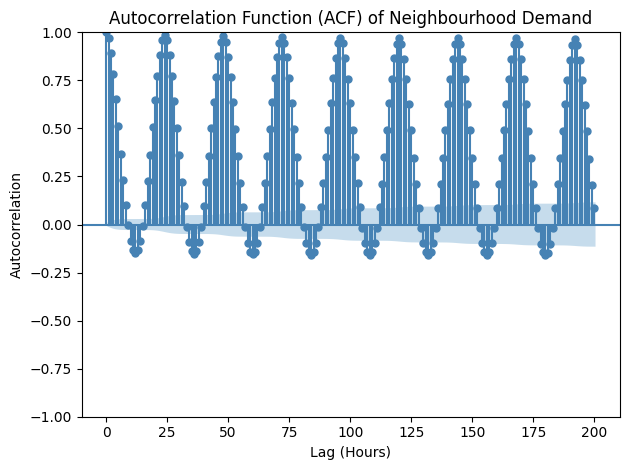

In [23]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(12, 4))
plot_acf(neighbourhood_demand["total_demand"].dropna(), lags=200, alpha=0.05,
         color="steelblue", vlines_kwargs={"colors": "steelblue"})
plt.title("Autocorrelation Function (ACF) of Neighbourhood Demand")
plt.xlabel("Lag (Hours)")
plt.ylabel("Autocorrelation")
plt.tight_layout()
plt.show()

<p>The ACF plot is arguably the most analytically significant chart in the entire EDA and provides the strongest statistical justification for the use of an LSTM network in this forecasting task. The plot displays a striking and unmistakable repeating spike pattern where autocorrelation surges to approximately 0.90 or above at every multiple of 24 lags — that is at lag 24, 48, 72, 96, 120, 144, 168, 192 and so on before dropping sharply to negative values of around -0.25 at the midpoints between these peaks. This perfectly regular comb-like structure is the definitive statistical signature of a strong 24-hour daily cycle, confirming that electricity demand at any given hour is almost perfectly correlated with demand at the same hour on every preceding day across the entire dataset. The fact that these autocorrelation spikes remain consistently high at 0.85 to 0.90 even out to lag 192  representing eight full days  without any meaningful decay demonstrates that the daily periodicity in this dataset is extraordinarily stable and persistent across time rather than being a short-lived local pattern. The negative autocorrelation values at the midpoints between peaks, around lags 12, 36, 60 and so on, reflect the inverse relationship between daytime peak hours and overnight trough hours  when demand is high during the day it is predictably low twelve hours later at night. All autocorrelation values fall well outside the light blue confidence interval bands confirming that every lag shown is statistically significant and not the result of random noise. This ACF result conclusively validates the choice of a 24-hour lookback window for sequence construction and confirms that an LSTM architecture  which is specifically designed to retain information across long sequential dependencies is the most appropriate modelling approach for this dataset.</p>

<h3 class = 'usecase-subsection-header'> Year-on-Year Demand Comparison — Area Chart </h3>
<p>
Overlaying the demand profiles of each year on the same axis allows for a direct year-on-year comparison of electricity consumption patterns. An area chart is used here to emphasise the volume of demand over time, making it straightforward to identify whether overall consumption is growing, declining, or remaining stable across 2012, 2013, and 2014 — an important consideration for long-term energy infrastructure planning in smart cities.
</p>

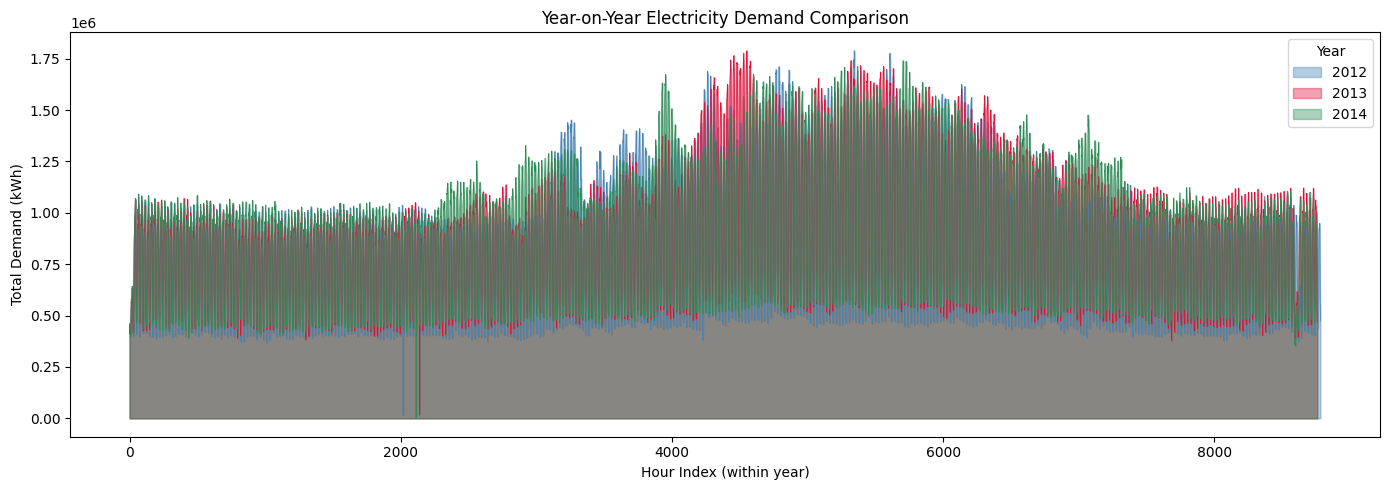

In [24]:
fig, ax = plt.subplots(figsize=(14, 5))

colours = ["steelblue", "crimson", "seagreen"]
for i, year in enumerate([2012, 2013, 2014]):
    yearly = neighbourhood_demand[neighbourhood_demand.index.year == year]["total_demand"]
    yearly = yearly.reset_index(drop=True)
    ax.fill_between(yearly.index, yearly.values, alpha=0.4, 
                    color=colours[i], label=str(year))
    ax.plot(yearly.index, yearly.values, color=colours[i], linewidth=0.5)

ax.set_title("Year-on-Year Electricity Demand Comparison")
ax.set_xlabel("Hour Index (within year)")
ax.set_ylabel("Total Demand (kWh)")
ax.legend(title="Year")
plt.tight_layout()
plt.show()

<p>The year-on-year area chart overlaying 2012, 2013, and 2014 consumption profiles reveals a remarkably consistent demand structure across all three years, with the three coloured bands — blue for 2012, red for 2013, and green for 2014 — overlapping so heavily that they appear almost as a single unified shape across the majority of the timeline. This near-perfect overlap confirms that the seasonal demand cycle repeats with very high fidelity year on year, with all three years displaying the same characteristic pattern of moderate demand in the early hours of the year (January to March, corresponding to hour indices 0 to approximately 2,000), a pronounced mid-year summer peak between hour indices 3,500 and 6,000 where demand regularly reaches 1,500,000 to 1,750,000 kWh, and a gradual decline back through the final quarter. The peak region around hour indices 4,000 to 5,500 shows the greatest spread between years with occasional instances where one year's demand visibly extends above the others, suggesting that the intensity of the summer peak varies slightly year to year likely due to differences in summer temperatures and heatwave events. The two sharp vertical drops visible at approximately hour index 2,200 in the blue and red bands correspond to the daylight saving time anomaly hours previously identified. Overall this plot provides the most direct confirmation that the three years of data are sufficiently consistent and comparable to be used together as a unified training dataset for the LSTM model, and that patterns learnt from 2012 and 2013 will generalise reliably to forecasting 2014 demand.</p>

<h3 class = 'usecase-subsection-header'>Weekday vs Weekend Demand </h3>
<p>A violin plot comparing weekday and weekend electricity demand distributions reveals not just the average difference in consumption between the two groups, but also the full shape of each distribution. The width of the violin at any demand level indicates how frequently that level occurs, providing a nuanced picture of how human activity patterns on working days versus rest days translate into distinctly different electricity demand profiles.</p>

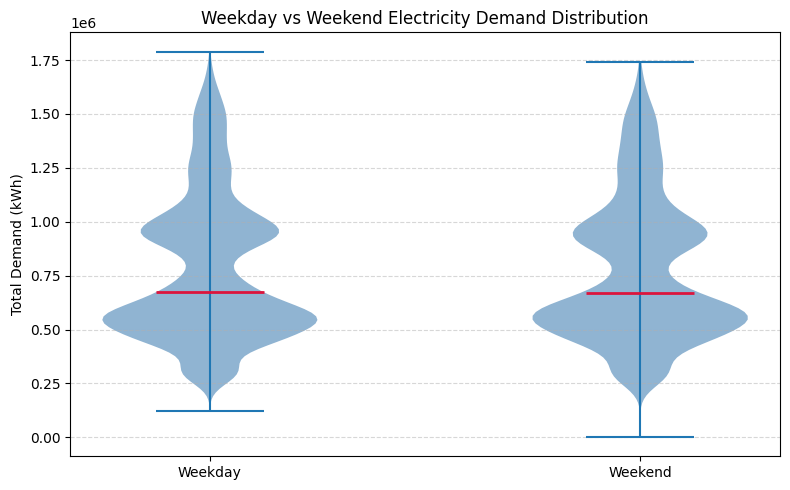

In [25]:
weekday_demand = neighbourhood_demand[neighbourhood_demand["dayofweek"] < 5]["total_demand"]
weekend_demand = neighbourhood_demand[neighbourhood_demand["dayofweek"] >= 5]["total_demand"]

fig, ax = plt.subplots(figsize=(8, 5))
parts = ax.violinplot([weekday_demand.values, weekend_demand.values],
                      positions=[1, 2], showmedians=True, showextrema=True)

for pc in parts["bodies"]:
    pc.set_facecolor("steelblue")
    pc.set_alpha(0.6)
parts["cmedians"].set_color("crimson")
parts["cmedians"].set_linewidth(2)

ax.set_xticks([1, 2])
ax.set_xticklabels(["Weekday", "Weekend"])
ax.set_title("Weekday vs Weekend Electricity Demand Distribution")
ax.set_ylabel("Total Demand (kWh)")
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

<p>The violin plot comparing weekday and weekend electricity demand distributions reveals that the two groups are strikingly similar in both shape and central tendency, which is entirely consistent with the findings from the day-of-week bar chart and the heatmap earlier in the EDA. Both violins display the same distinctive bimodal shape  wide at the lower demand region around 500,000 to 600,000 kWh and bulging again at the upper demand region around 950,000 to 1,000,000 kWh  directly mirroring the bimodal distribution identified in the histogram and confirming that this two-regime demand structure holds equally across both weekdays and weekends. The red median lines for both groups sit at virtually identical levels of approximately 670,000 kWh, confirming that the central tendency of demand does not shift meaningfully between working days and rest days. The weekday violin is very marginally wider in the upper bulge region compared to the weekend violin, suggesting that the highest daytime demand levels are reached slightly more frequently and more intensely on weekdays  consistent with the additional commercial load present during the working week. The whiskers of both violins extend down to near zero, again reflecting the daylight saving time anomaly hours rather than genuine demand collapses. Overall this violin plot conclusively confirms that day type weekday versus weekend is not a significant driver of demand variability in this dataset, and that the LSTM model should prioritise learning the time-of-day and seasonal patterns identified throughout the EDA over any weekday-weekend distinction.
</p>